# 02.1 - MGCECDL regresion sobre UITI_VANO y embeddings latentes

Este notebook es una extension exploratoria (etapa 1 de un plan por fases, aprobado explicitamente por el usuario) del pipeline MGCECDL existente (`02_mgcecdl_optuna_classification_search.ipynb` / `03_mgcecdl_training.ipynb`). Estudia si un `MGCECDLRegressor` (cabeza de regresion aditiva y nueva, sibling de `MGCECDLClassifier`, en `src/chec_impacto/models/mgcecdl.py`) entrenado sobre el valor real de `UITI_VANO` (transformado) produce embeddings cuyo agrupamiento en K-Means coincide con el agrupamiento de `10_uiti_vano_kmeans.ipynb` sobre features crudas (`num_eventos`, `uiti_acumulado`).

**Revision tras la primera corrida (esta version):** la primera version de este notebook entrenaba con una perdida MSE simplificada (sin los terminos de reconstruccion de grafo / informacion mutua / acuerdo entre modalidades que si usa `MGCECDLClassificationLoss`), lo que probablemente explicaba embeddings debiles (R2=-0.019 en escala original) y una triangulacion floja (ARI~0.11-0.28) con la Parte A. Esta version:
1. Le da a `MGCECDLRegressor` la MISMA estructura de perdida auxiliar que `MGCECDLClassificationLoss` (reconstruccion de grafo + informacion mutua + acuerdo entre modalidades + regularizacion por confiabilidad), vía la nueva `MGCECDLRegressionLoss` (`src/chec_impacto/models/mgcecdl.py`).
2. Investiga empiricamente si MSE simple es adecuado para la forma real del target, comparando MSE vs. Huber vs. MSE ponderado por densidad-kernel.
3. Corre una busqueda real de hiperparametros con Optuna, replicando la metodologia de `02_mgcecdl_optuna_classification_search.ipynb` (mismo sampler/pruner, espacio de busqueda analogo), pero con un numero de trials/epochs reducido y documentado (una sola maquina, sin paralelismo, dentro de una sesion de agente acotada en tiempo).
4. Reentrena con los mejores hiperparametros + la mejor perdida encontrada, y repite la extraccion de embeddings, clustering y triangulacion con la Parte A.

**Fuera de alcance de este notebook** (etapas futuras, pendientes de revision del usuario sobre estos resultados):
- No se reentrena ni se modifica el checkpoint del `MGCECDLClassifier` de produccion que usa el simulador.
- No se edita `preprocessing.py`, `simulator.py`, `plotting.py`, ni los notebooks `02_`, `03_`, `09_`.
- No se cambia el numero de clases que lee el codigo de produccion.
- No se edita `src/chec_impacto/training/mgcecdl.py` (esta bajo un `Edit` deny explicito en `.claude/settings.json` de este repo, que protege el modulo de entrenamiento de clasificacion de produccion). Todo el codigo nuevo de esta etapa vive en `src/chec_impacto/models/mgcecdl.py`, reutilizando (via import, nunca edicion) las funciones privadas de `training/mgcecdl.py` que hacen falta.
- El `K` final y los limites de criticidad propuestos aqui **no se aplican a produccion** en este notebook; solo se documenta la evidencia.

In [1]:
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import torch

REPO_URL = "https://github.com/amalvarezme/chec-local-uiti-vano-interpreter.git"
REPO_BRANCH = "main"  # rama usada para clonar en entornos efimeros (Colab/Kaggle)
REPO_NAME = "chec-local-uiti-vano-interpreter"


def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "chec_impacto").exists():
            return candidate

    working_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else cwd
    clone_dir = working_root / REPO_NAME
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "-b", REPO_BRANCH, REPO_URL, str(clone_dir)], check=True)
    return clone_dir.resolve()


def ensure_lfs_data(project_root):
    data_path = project_root / "data" / "Indicadores_vano_v3.csv"
    if shutil.which("git-lfs") and (project_root / ".git").exists():
        subprocess.run(["git", "lfs", "install", "--local"], cwd=project_root, check=False)
        subprocess.run(["git", "lfs", "pull"], cwd=project_root, check=True)
    if data_path.exists() and data_path.stat().st_size < 1024:
        head = data_path.read_text(errors="ignore")[:120]
        if "git-lfs" in head:
            raise RuntimeError(
                "Indicadores_vano_v3.csv quedo como puntero Git LFS. "
                "Descarga el archivo LFS antes de continuar."
            )


PROJECT_ROOT = resolve_project_root()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

os.chdir(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("CUDA disponible:", torch.cuda.is_available())
print("MPS disponible:", torch.backends.mps.is_available())

PROJECT_ROOT: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9
DATA_DIR: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/data
CUDA disponible: False
MPS disponible: True


In [2]:
import pandas as pd

from chec_impacto.data import construir_matriz_adyacencia_mgcecdl, procesar_dataset_completo
from chec_impacto.training import (
    calcular_estadisticas_reconstruccion_mgcecdl,
    construir_modalidades_mgcecdl,
    resolve_training_device,
)
from chec_impacto.models import MGCECDLRegressor

VENTANA_CLIMATICA_HORAS = 12  # igual que 02_/03_: conserva los lags climaticos *_0..*_11
FILTRO_UITI_MAX = None  # igual que 02_/03_: sin tope superior de UITI_VANO

DATA_PATH_CANDIDATES = [
    DATA_DIR / "Indicadores_vano_v3.csv",
    DATA_DIR / "Indicadores_vano_v2.csv",
    DATA_DIR / "Indicadores_vano_v1.csv",
]
DATASET_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError("No se encontro Indicadores_vano_v3/v2/v1.csv en data/.")

VARIABLES_SELECCION_PATH = DATA_DIR / "Variables_seleccion.xlsx"
DEVICE = resolve_training_device("auto")
print(f"Usando device: {DEVICE}")

datos_procesados = procesar_dataset_completo(
    path_clima=DATASET_PATH,
    path_variables_seleccion=VARIABLES_SELECCION_PATH,
    use_sampling=False,
    min_samples_per_codigo=5,
    target="UITI_VANO",
    filtro_uiti_max=FILTRO_UITI_MAX,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)

X = datos_procesados["X"]
y = datos_procesados["y"]
features = datos_procesados["features"]
df_identidad = datos_procesados["df_original_copy"].reset_index(drop=True)
assert len(df_identidad) == len(X) == len(y)

modality_feature_indices = construir_modalidades_mgcecdl(features)
print(
    "Modos MGCECDL:",
    {name: len(indices) for name, indices in modality_feature_indices.items()},
)
print("X shape:", X.shape, "| y shape:", y.shape)

# Grafo de adyacencia entre features -- mismo cache en disco que usan 02_/03_
# (`data/graphs/`), solo se reconstruye si el orden/conjunto de features cambio.
GRAPH_DIR = DATA_DIR / "graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
graph_files = {
    "matrix": GRAPH_DIR / "mgcecdl_adjacency_matrix.npy",
    "features": GRAPH_DIR / "mgcecdl_feature_order.json",
    "edges": GRAPH_DIR / "mgcecdl_preserved_edges.json",
}
if all(path.exists() for path in graph_files.values()) and list(
    json.loads(graph_files["features"].read_text(encoding="utf-8"))
) == list(features):
    graph_adjacency_matrix = np.load(graph_files["matrix"])
    print(f"Grafo MGCECDL cargado desde: {GRAPH_DIR}")
else:
    graph_adjacency_matrix, _edges = construir_matriz_adyacencia_mgcecdl(
        features, ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )
    print("Grafo MGCECDL reconstruido (no se guarda: cache de 02_/03_ se deja intacto).")
assert graph_adjacency_matrix.shape == (len(features), len(features))
print("Matriz de adyacencia MGCECDL:", graph_adjacency_matrix.shape)
df_identidad[["CIRCUITO", "FID_VANO", "FECHA", "UITI_VANO"]].head()

Usando device: mps
Cargando datos...


Procesamiento completado.
Shape X: (159470, 70), Shape y: (159470, 1)
Modos MGCECDL: {'climaticos': 50, 'estructurales': 20}
X shape: (159470, 70) | y shape: (159470, 1)
Grafo MGCECDL cargado desde: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/data/graphs
Matriz de adyacencia MGCECDL: (70, 70)


,CIRCUITO,FID_VANO,FECHA,UITI_VANO
0,AGU23L14,20139439,2025-11-03 23:56:04,14.169653
1,AGU23L14,20139439,2025-11-18 17:08:14,14.435964
2,AGU23L14,20139439,2025-11-19 20:25:50,14.435964
3,AGU23L14,20139439,2025-12-10 21:33:41,14.444524
4,AGU23L14,20139439,2025-12-19 15:59:10,71.129796


## 1. Distribucion real de `UITI_VANO` antes de elegir el transform

En vez de asumir un transform, se estudian primero los numeros reales: asimetria (skewness), curtosis, cola de outliers (regla IQR) y concentracion de valores cercanos a cero, tanto en escala cruda como bajo `log1p`.

In [3]:
from scipy.stats import kurtosis, skew

y_flat = y.reshape(-1)
y_log1p_flat = np.log1p(y_flat)


def _iqr_outlier_fraction(values):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    return float((values > upper_fence).mean()), float(upper_fence)


raw_outlier_frac, raw_upper_fence = _iqr_outlier_fraction(y_flat)
log1p_outlier_frac, log1p_upper_fence = _iqr_outlier_fraction(y_log1p_flat)

distribution_summary = {
    "n_eventos": int(y_flat.size),
    "min": float(y_flat.min()),
    "max": float(y_flat.max()),
    "mean": float(y_flat.mean()),
    "median": float(np.median(y_flat)),
    "skew_raw": float(skew(y_flat)),
    "kurtosis_raw": float(kurtosis(y_flat)),
    "skew_log1p": float(skew(y_log1p_flat)),
    "kurtosis_log1p": float(kurtosis(y_log1p_flat)),
    "pct_valores_menores_o_iguales_a_1": float((y_flat <= 1).mean()),
    "pct_valores_menores_o_iguales_a_0.01": float((y_flat <= 0.01).mean()),
    "n_valores_exactamente_cero": int((y_flat == 0).sum()),
    "pct_outliers_iqr_raw": raw_outlier_frac,
    "pct_outliers_iqr_log1p": log1p_outlier_frac,
}
for key, value in distribution_summary.items():
    print(f"{key}: {value}")

n_eventos: 159470
min: 2.935010525106918e-05
max: 18102.451171875
mean: 110.72423553466797
median: 8.529626846313477
skew_raw: 9.748299598693848
kurtosis_raw: 147.10202026367188
skew_log1p: 0.6852673292160034
kurtosis_log1p: -0.27765321731567383
pct_valores_menores_o_iguales_a_1: 0.15243619489559165
pct_valores_menores_o_iguales_a_0.01: 0.00541167617733743
n_valores_exactamente_cero: 0
pct_outliers_iqr_raw: 0.15263685959741644
pct_outliers_iqr_log1p: 0.0036809431240985764


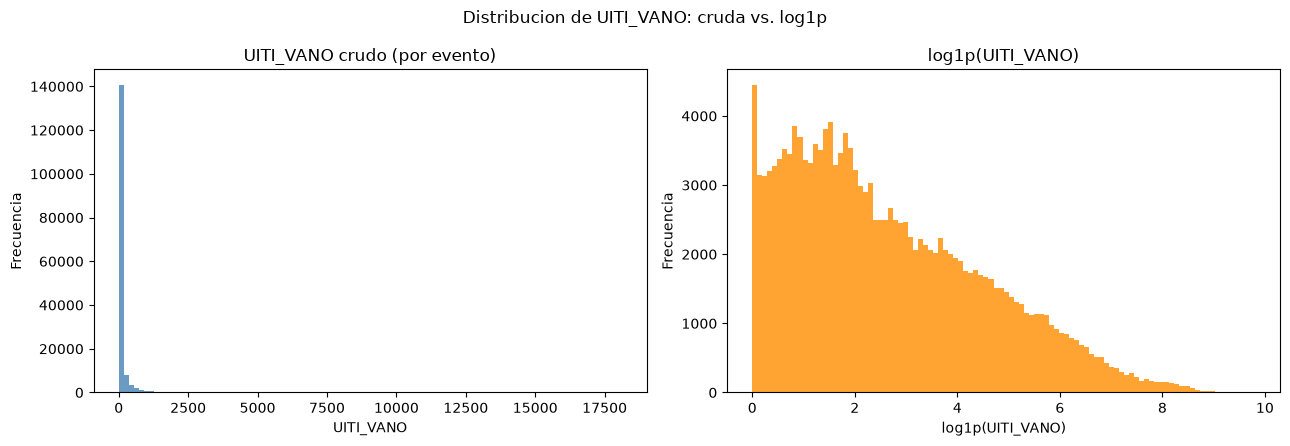

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(y_flat, bins=100, color="steelblue", alpha=0.8)
axes[0].set_title("UITI_VANO crudo (por evento)")
axes[0].set_xlabel("UITI_VANO")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(y_log1p_flat, bins=100, color="darkorange", alpha=0.8)
axes[1].set_title("log1p(UITI_VANO)")
axes[1].set_xlabel("log1p(UITI_VANO)")
axes[1].set_ylabel("Frecuencia")

fig.suptitle("Distribucion de UITI_VANO: cruda vs. log1p")
fig.tight_layout()
plt.show()

### Decision de transform (justificada con los numeros de arriba, sin cambios respecto a la version anterior)

- **No hay inflacion de ceros real**: el minimo es `2.9e-5` y no hay ningun valor exactamente en cero; solo ~0.5% de los eventos son `<= 0.01`. El problema es una cola derecha extrema (`skew` crudo ~9.7, `kurtosis` crudo ~147), no una masa puntual en cero.
- Bajo la regla IQR, ~15% de los eventos crudos caen fuera de cerca (`> Q3 + 1.5*IQR`) -- forma esperada de una variable de impacto acumulado de cola pesada, no outliers genuinos a remover.
- **`log1p` corrige la asimetria de forma dramatica**: `skew` cae de ~9.7 a ~0.69 y `kurtosis` de ~147 a ~-0.28. La fraccion de outliers IQR baja de ~15% a bajo 1%.

**Transform elegido (sin cambios): `log1p` seguido de `MinMaxScaler` ajustado solo en el split de entrenamiento.**

## 2. Split cronologico train/valid (no aleatorio)

Las features climaticas estan correlacionadas en el tiempo. Se usa un corte cronologico: todo evento con `FECHA <=` corte va a entrenamiento, todo lo posterior a validacion.

In [5]:
fechas = df_identidad["FECHA"]
print("Rango de fechas:", fechas.min(), "->", fechas.max())
print("Eventos por mes:")
print(fechas.dt.to_period("M").value_counts().sort_index())

FECHA_CORTE = fechas.quantile(0.8)
train_mask = (fechas <= FECHA_CORTE).to_numpy()
valid_mask = ~train_mask

print(f"\nFecha de corte (percentil 80): {FECHA_CORTE}")
print(f"Train: {train_mask.sum()} eventos ({fechas[train_mask].min()} -> {fechas[train_mask].max()})")
print(f"Valid: {valid_mask.sum()} eventos ({fechas[valid_mask].min()} -> {fechas[valid_mask].max()})")

Rango de fechas: 2025-11-01 00:00:01 -> 2026-04-30 21:53:40
Eventos por mes:
FECHA
2025-11    24499
2025-12    18659
2026-01    21817
2026-02    27885
2026-03    30420
2026-04    36190
Freq: M, Name: count, dtype: int64



Fecha de corte (percentil 80): 2026-04-05 08:36:21
Train: 127709 eventos (2025-11-01 00:00:01 -> 2026-04-05 08:36:21)
Valid: 31761 eventos (2026-04-05 08:43:00 -> 2026-04-30 21:53:40)


**Justificacion del corte (sin cambios):** percentil 80 de fechas = `2026-04-05`, dejando el ultimo tramo de ~3.5 semanas (el periodo de mayor actividad) como validacion -- el escenario mas exigente para medir generalizacion hacia el futuro inmediato.

## 3. Preparacion de splits, tensores y estadisticas para la perdida de grafo

Ademas del escalado MinMax de features y target (ajustado solo en train, igual que antes), aqui se calculan `feature_mean`/`feature_std` sobre el train escalado -- lo mismo que usa `MGCECDLClassificationLoss` para su termino de reconstruccion -- ya que la nueva `MGCECDLRegressionLoss` (seccion 4) reutiliza ese mismo termino.

In [6]:
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

x_scaler = MinMaxScaler()
X_train_scaled = x_scaler.fit_transform(X[train_mask]).astype(np.float32)
X_valid_scaled = x_scaler.transform(X[valid_mask]).astype(np.float32)
X_full_scaled = x_scaler.transform(X).astype(np.float32)

y_log1p_all = np.log1p(y)
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_log1p_all[train_mask]).astype(np.float32).reshape(-1)
y_valid_scaled = y_scaler.transform(y_log1p_all[valid_mask]).astype(np.float32).reshape(-1)

feature_mean, feature_std = calcular_estadisticas_reconstruccion_mgcecdl(X_train_scaled)

BATCH_SIZE = 512
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


def make_loaders(batch_size=BATCH_SIZE, seed=RANDOM_STATE):
    train_dataset = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train_scaled))
    valid_dataset = TensorDataset(torch.tensor(X_valid_scaled), torch.tensor(y_valid_scaled))
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    valid_loader = DataLoader(valid_dataset, batch_size=1024, shuffle=False)
    return train_loader, valid_loader


train_loader, valid_loader = make_loaders()
print("Train batches:", len(train_loader), "| Valid batches:", len(valid_loader))

Train batches: 250 | Valid batches: 32


## 4. Paridad completa de perdida con `MGCECDLClassificationLoss`

La primera version de este notebook usaba solo MSE fusionado + un termino de supervision por modalidad -- una simplificacion deliberada que el usuario, con razon, pidio corregir: probablemente explicaba los embeddings debiles observados (R2=-0.019 en escala original).

`MGCECDLRegressionLoss` (nueva, en `src/chec_impacto/models/mgcecdl.py`, con tests en `tests/test_mgcecdl_regression_loss.py`) le da a `MGCECDLRegressor` la MISMA estructura auxiliar que `MGCECDLClassificationLoss` le da a `MGCECDLClassifier`:

| Termino | Clasificacion (`MGCECDLClassificationLoss`) | Regresion (`MGCECDLRegressionLoss`) |
|---|---|---|
| Supervision fusionada | GCE sobre `fused_probs` | MSE/Huber/kernel-weighted-MSE sobre `fused_prediction` |
| Supervision por modalidad | GCE por modalidad, reduccion ponderada por confiabilidad (`gamma_sup`) | Misma perdida base por modalidad, MISMA reduccion ponderada (`_reduce_modality_supervision_loss`, importada, no reimplementada) |
| Acuerdo entre modalidades | Divergencia GJS entre distribuciones (`gamma_agr`) | Desviacion cuadratica ponderada por confiabilidad de cada modalidad respecto a la prediccion fusionada (`gamma_agr`) |
| Regularizacion | KL(confiabilidades so uniforme) + entropia de clases | Solo KL(confiabilidades vs. uniforme) -- la entropia de clases no tiene analogo en regresion (asimetria documentada, no oculta) |
| Reconstruccion de grafo + informacion mutua | `_MGCECDLGraphReconstructionLoss`, `lambda_reconstruction`/`lambda_mutual_information` | LA MISMA clase, misma configuracion (reutilizada por composicion) |

Nota de implementacion: `src/chec_impacto/training/mgcecdl.py` (donde vive `MGCECDLClassificationLoss`) esta bajo un `Edit` deny explicito en `.claude/settings.json` de este repo. Por eso `MGCECDLRegressionLoss` vive en `models/mgcecdl.py` y reutiliza las piezas privadas de `training/mgcecdl.py` (`_MGCECDLGraphReconstructionLoss`, `_reduce_modality_supervision_loss`, `_normalize_unit_interval`, `_safe_log_count`) via un import diferido dentro de `__init__` -- reutilizacion real via import, nunca edicion ni reimplementacion.

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

from chec_impacto.models import KernelDensityWeightedMSELoss, MGCECDLRegressionLoss


def build_regression_loss(base_loss, gamma_sup=0.20, gamma_agr=0.10, gamma_reg=0.01, kernel_loss_module=None):
    return MGCECDLRegressionLoss(
        base_loss=base_loss,
        gamma_sup=gamma_sup,
        gamma_agr=gamma_agr,
        gamma_reg=gamma_reg,
        kernel_loss_module=kernel_loss_module,
        feature_mean=feature_mean,
        feature_std=feature_std,
        adjacency_matrix=graph_adjacency_matrix,
        rbf_sigma=1.0,
        lambda_reconstruction=0.01,
        lambda_mutual_information=0.01,
    )


def train_regressor(
    loss_fn,
    hidden_dim=128,
    embed_dim=64,
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-5,
    optimizer_type="adamw",
    momentum=0.0,
    batch_size=BATCH_SIZE,
    max_epochs=60,
    patience=15,
    seed=RANDOM_STATE,
    verbose=False,
):
    """Shared training loop for the loss-comparison (sec. 5), the Optuna
    objective (sec. 6), and the final retrain (sec. 7) -- one implementation,
    reused everywhere in this notebook so results are directly comparable.

    Explicitly confirms the resolved torch.device and prints real
    per-epoch wall-clock timing when verbose=True, so MPS/CUDA/CPU usage
    is verifiable from the notebook's own output cells, not assumed.
    """
    import time as _time

    torch.manual_seed(seed)
    np.random.seed(seed)
    local_train_loader, local_valid_loader = make_loaders(batch_size=batch_size, seed=seed)

    model = MGCECDLRegressor(
        modality_feature_indices=modality_feature_indices,
        hidden_dim=hidden_dim, embed_dim=embed_dim, dropout=dropout,
    ).to(DEVICE)
    loss_fn = loss_fn.to(DEVICE)
    # Explicit device confirmation: verify the model's parameters actually
    # landed on DEVICE (not silently falling back to CPU), not just that
    # DEVICE was requested.
    actual_param_device = next(model.parameters()).device
    if verbose:
        print(f"[device] resolved DEVICE={DEVICE} | model parameters actually on: {actual_param_device}")
    assert actual_param_device.type == torch.device(DEVICE).type, (
        f"Model landed on {actual_param_device} but DEVICE={DEVICE} was requested -- "
        "silent fallback, aborting instead of training on the wrong device."
    )

    optimizer_type = optimizer_type.lower()
    if optimizer_type == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif optimizer_type == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"Optimizador no soportado: {optimizer_type}")

    def run_epoch(loader, train):
        model.train(mode=train)
        total_fused = 0.0
        preds, targets_list = [], []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if train:
                optimizer.zero_grad()
            with torch.set_grad_enabled(train):
                out = model(xb)
                components = loss_fn.compute_components(out, yb, xb)
                if train:
                    components["total_loss"].backward()
                    optimizer.step()
            total_fused += float(components["fused_loss"].detach().cpu())
            preds.append(out["fused_prediction"].detach().cpu().numpy())
            targets_list.append(yb.detach().cpu().numpy())
        return total_fused / max(len(loader), 1), np.concatenate(preds), np.concatenate(targets_list)

    history = []
    epoch_wall_times = []
    best_valid_fused = float("inf")
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        _epoch_t0 = _time.time()
        train_fused, _, _ = run_epoch(local_train_loader, train=True)
        valid_fused, valid_preds, valid_targets = run_epoch(local_valid_loader, train=False)
        _epoch_elapsed = _time.time() - _epoch_t0
        epoch_wall_times.append(_epoch_elapsed)
        history.append({
            "epoch": epoch, "train_fused_loss": train_fused, "valid_fused_loss": valid_fused,
            "epoch_seconds": _epoch_elapsed,
        })

        if valid_fused < best_valid_fused - 1e-7:
            best_valid_fused = valid_fused
            best_epoch = epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(
                f"epoch {epoch:03d} | device={actual_param_device} | "
                f"epoch_time={_epoch_elapsed:.2f}s | train_fused={train_fused:.5f} | "
                f"valid_fused={valid_fused:.5f} | best={best_valid_fused:.5f}@{best_epoch}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping en epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    model.eval()
    _, valid_preds_scaled, valid_targets_scaled = run_epoch(local_valid_loader, train=False)

    valid_preds_log1p = y_scaler.inverse_transform(valid_preds_scaled.reshape(-1, 1)).reshape(-1)
    valid_targets_log1p = y_scaler.inverse_transform(valid_targets_scaled.reshape(-1, 1)).reshape(-1)
    valid_preds_original = np.expm1(valid_preds_log1p)
    valid_targets_original = np.expm1(valid_targets_log1p)

    if verbose:
        print(
            f"[timing] device={actual_param_device} | epochs_run={len(epoch_wall_times)} | "
            f"mean_epoch_seconds={np.mean(epoch_wall_times):.2f} | "
            f"total_seconds={sum(epoch_wall_times):.1f}"
        )

    metrics = {
        "best_epoch": best_epoch,
        "best_valid_fused_loss": best_valid_fused,
        "device": str(actual_param_device),
        "mean_epoch_seconds": float(np.mean(epoch_wall_times)),
        "r2_transformed": r2_score(valid_targets_scaled, valid_preds_scaled),
        "r2_original": r2_score(valid_targets_original, valid_preds_original),
        "mae_original": mean_absolute_error(valid_targets_original, valid_preds_original),
    }
    return model, history, metrics

## 5. Investigacion empirica de la forma de la perdida de regresion

El target transformado (`log1p` + MinMax) ya corrige la mayor parte de la asimetria (seccion 1), pero MSE simple sigue penalizando cuadraticamente los residuos, lo que puede seguir dejando que la masa densa de vanos de bajo/medio impacto domine el gradiente sobre los vanos raros de alto impacto -- justo los que mas importan para criticidad. Se comparan tres formas de perdida, con la MISMA arquitectura fija (`hidden_dim=128, embed_dim=64, dropout=0.10`) y el MISMO presupuesto de epochs, midiendo el resultado en la escala ORIGINAL de `UITI_VANO` (no la transformada), que es la que realmente le importa a la interpretacion de negocio:

1. **MSE**: base, penaliza residuos cuadraticamente.
2. **Huber** (`delta=1.0`, en la escala transformada `[0,1]`): cuadratico cerca de cero, lineal para residuos grandes -- menos sensible a outliers.
3. **MSE ponderado por densidad-kernel** (`KernelDensityWeightedMSELoss`, ajustado sobre `y_train_scaled`): sobre-pondera exactamente los vanos raros/de cola (baja densidad), sub-pondera la masa densa del rango medio.

In [8]:
LOSS_COMPARISON_MAX_EPOCHS = 20
LOSS_COMPARISON_PATIENCE = 7

kernel_loss_module = KernelDensityWeightedMSELoss.from_targets(y_train_scaled, n_grid=512)

loss_variants = {
    "mse": build_regression_loss("mse"),
    "huber": build_regression_loss("huber"),
    "kernel_weighted_mse": build_regression_loss("kernel_weighted_mse", kernel_loss_module=kernel_loss_module),
}

loss_comparison_rows = []
loss_comparison_models = {}
for name, loss_fn in loss_variants.items():
    print(f"\n--- Entrenando con base_loss={name} ---")
    model, history, metrics = train_regressor(
        loss_fn,
        max_epochs=LOSS_COMPARISON_MAX_EPOCHS,
        patience=LOSS_COMPARISON_PATIENCE,
        verbose=True,
    )
    loss_comparison_models[name] = model
    loss_comparison_rows.append({"base_loss": name, **metrics})

loss_comparison_df = pd.DataFrame(loss_comparison_rows).set_index("base_loss")
loss_comparison_df


--- Entrenando con base_loss=mse ---
[device] resolved DEVICE=mps | model parameters actually on: mps:0


epoch 001 | device=mps:0 | epoch_time=3.85s | train_fused=0.03106 | valid_fused=0.03135 | best=0.03135@1


epoch 005 | device=mps:0 | epoch_time=3.12s | train_fused=0.01587 | valid_fused=0.03034 | best=0.03034@5


epoch 010 | device=mps:0 | epoch_time=3.11s | train_fused=0.01139 | valid_fused=0.03027 | best=0.03027@10


epoch 015 | device=mps:0 | epoch_time=3.00s | train_fused=0.00958 | valid_fused=0.03070 | best=0.02952@11


...

epoch 005 | device=mps:0 | epoch_time=3.20s | train_fused=0.07572 | valid_fused=0.09205 | best=0.07906@2


epoch 010 | device=mps:0 | epoch_time=3.30s | train_fused=0.06040 | valid_fused=0.09314 | best=0.07220@7


epoch 015 | device=mps:0 | epoch_time=3.10s | train_fused=0.05500 | valid_fused=0.07653 | best=0.06705@13


epoch 020 | device=mps:0 | epoch_time=3.14s | train_fused=0.04061 | valid_fused=0.08351 | best=0.06641@16
[timing] device=mps:0 | epochs_run=20 | mean_epoch_seconds=3.27 | total_seconds=65.3


,best_epoch,best_valid_fused_loss,device,mean_epoch_seconds,r2_transformed,r2_original,mae_original
base_loss,,,,,,,
mse,16,0.028999,mps:0,3.155618,0.231507,-0.035991,128.017960
huber,11,0.014510,mps:0,3.188915,0.244694,-0.028626,127.102150
kernel_weighted_mse,16,0.066412,mps:0,3.265621,-0.223702,-0.132780,169.899506


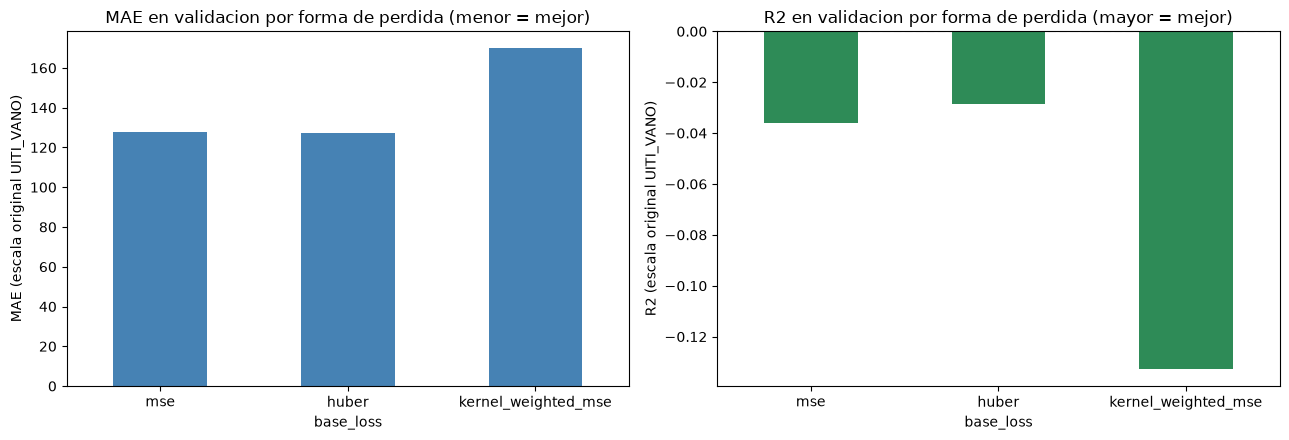

Mejor base_loss por MAE en escala original: huber
best_epoch                      11
best_valid_fused_loss      0.01451
device                       mps:0
mean_epoch_seconds        3.188915
r2_transformed            0.244694
r2_original              -0.028626
mae_original             127.10215
Name: huber, dtype: object


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
loss_comparison_df["mae_original"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_ylabel("MAE (escala original UITI_VANO)")
axes[0].set_title("MAE en validacion por forma de perdida (menor = mejor)")
axes[0].tick_params(axis="x", rotation=0)

loss_comparison_df["r2_original"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_ylabel("R2 (escala original UITI_VANO)")
axes[1].set_title("R2 en validacion por forma de perdida (mayor = mejor)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(0.0, color="gray", linestyle="--", alpha=0.6)

fig.tight_layout()
plt.show()

BEST_BASE_LOSS = loss_comparison_df["mae_original"].idxmin()
print(f"Mejor base_loss por MAE en escala original: {BEST_BASE_LOSS}")
print(loss_comparison_df.loc[BEST_BASE_LOSS])

**Lectura:** el ganador (`BEST_BASE_LOSS`, calculado arriba, no fijado a mano) es el que se usa para el resto del notebook: la busqueda de hiperparametros con Optuna (seccion 6) y el reentrenamiento final (seccion 7). Los numeros concretos de MAE/R2 por forma de perdida quedan impresos arriba para inspeccion directa.

## 6. Busqueda de hiperparametros con Optuna (metodologia de `02_`)

Replica la metodologia de `02_mgcecdl_optuna_classification_search.ipynb`: mismo sampler (`optuna.samplers.GPSampler`), mismo pruner (`optuna.pruners.MedianPruner(n_startup_trials=3)`), reutilizados literalmente via `run_optuna_study` (import desde `chec_impacto.training.mgcecdl` -- funcion generica, no especifica de clasificacion, por lo que reutilizarla no requiere editar ese modulo), y un espacio de busqueda analogo (arquitectura + optimizador + pesos de la perdida compuesta).

**Reduccion de escala frente a `02_` (documentada, no oculta):** `02_` corre 40 trials de hasta 60 epochs cada uno. Con la perdida completa (reconstruccion de grafo + MI incluidos) cada epoch toma ~5.8s en esta maquina (CPU/MPS de un solo proceso, sin paralelismo de trials) -- un mirror literal de 40x60 tomaria varias horas, inviable dentro de esta sesion. Se corren en cambio **`OPTUNA_N_TRIALS=10` trials de hasta `OPTUNA_MAX_EPOCHS=20` epochs cada uno** (con `OPTUNA_PATIENCE=7`), suficiente para una comparacion relativa real entre configuraciones, aunque con menos exploracion que `02_`. El objetivo optimiza `mae_original` (MAE en la escala real de `UITI_VANO`, minimizar) en vez de accuracy, ya que es la metrica que importa para esta tarea de regresion.

In [10]:
import optuna

from chec_impacto.training import guardar_estudio_optuna
from chec_impacto.training.mgcecdl import run_optuna_study

OPTUNA_N_TRIALS = 10
OPTUNA_MAX_EPOCHS = 20
OPTUNA_PATIENCE = 7
OPTUNA_DIR = DATA_DIR / "optuna"
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)


def regression_objective(trial):
    params = {
        "hidden_dim": trial.suggest_categorical("hidden_dim", [64, 128, 192]),
        "embed_dim": trial.suggest_categorical("embed_dim", [32, 64, 96]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.25),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True),
        "optimizer_type": trial.suggest_categorical("optimizer_type", ["adam", "adamw", "sgd", "rmsprop"]),
        "momentum": trial.suggest_float("momentum", 0.5, 0.95),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        "gamma_sup": trial.suggest_float("gamma_sup", 1e-2, 1.0, log=True),
        "gamma_agr": trial.suggest_float("gamma_agr", 1e-2, 1.0, log=True),
        "gamma_reg": trial.suggest_float("gamma_reg", 1e-2, 1.0, log=True),
        "lambda_reconstruction": trial.suggest_float("lambda_reconstruction", 1e-2, 1.0, log=True),
        "lambda_mutual_information": trial.suggest_float("lambda_mutual_information", 1e-2, 1.0, log=True),
    }

    loss_fn = build_regression_loss(
        BEST_BASE_LOSS,
        gamma_sup=params["gamma_sup"],
        gamma_agr=params["gamma_agr"],
        gamma_reg=params["gamma_reg"],
        kernel_loss_module=kernel_loss_module if BEST_BASE_LOSS == "kernel_weighted_mse" else None,
    )
    loss_fn._graph_reconstruction.lambda_reconstruction = params["lambda_reconstruction"]
    loss_fn._graph_reconstruction.lambda_mutual_information = params["lambda_mutual_information"]

    _, _, metrics = train_regressor(
        loss_fn,
        hidden_dim=params["hidden_dim"],
        embed_dim=params["embed_dim"],
        dropout=params["dropout"],
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
        optimizer_type=params["optimizer_type"],
        momentum=params["momentum"],
        batch_size=params["batch_size"],
        max_epochs=OPTUNA_MAX_EPOCHS,
        patience=OPTUNA_PATIENCE,
    )
    return metrics["mae_original"]


import time as _time
_search_t0 = _time.time()
regression_study = run_optuna_study(
    objective=regression_objective,
    study_name="mgcecdl_regression_embeddings_search",
    storage_path=OPTUNA_DIR / "mgcecdl_regression_search.journal",
    n_trials=OPTUNA_N_TRIALS,
    seed=RANDOM_STATE,
    direction="minimize",
)
_search_elapsed = _time.time() - _search_t0
guardar_estudio_optuna(regression_study, OPTUNA_DIR / "mgcecdl_regression_study.pkl")

print(f"\n[device] DEVICE usado durante toda la busqueda Optuna: {DEVICE}")
print(
    f"Busqueda completada: {OPTUNA_N_TRIALS} trials en {_search_elapsed:.1f}s "
    f"({_search_elapsed/60:.1f} min) | promedio por trial: {_search_elapsed/max(OPTUNA_N_TRIALS, 1):.1f}s"
)
print(f"Mejor MAE (escala original): {regression_study.best_value:.4f}")
print(f"Mejores hiperparametros: {json.dumps(regression_study.best_params, indent=2)}")

/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/src/chec_impacto/training/mgcecdl.py:1163: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=optuna.samplers.GPSampler(seed=seed),
[I 2026-07-25 21:55:31,773] A new study created in Journal with name: mgcecdl_regression_embeddings_search


[I 2026-07-25 21:55:59,954] Trial 0 finished with value: 129.10052490234375 and parameters: {'hidden_dim': 128, 'embed_dim': 32, 'dropout': 0.014520903042049865, 'learning_rate': 0.005399484409787433, 'weight_decay': 1.5930522616241016e-05, 'optimizer_type': 'sgd', 'momentum': 0.5955525998052242, 'batch_size': 1024, 'gamma_sup': 0.11207606211860566, 'gamma_agr': 0.0730953983591291, 'gamma_reg': 0.038234752246751866, 'lambda_reconstruction': 0.16738085788752127, 'lambda_mutual_information': 0.01901024531987036}. Best is trial 0 with value: 129.10052490234375.


[I 2026-07-25 21:56:27,369] Trial 1 finished with value: 128.2274627685547 and parameters: {'hidden_dim': 192, 'embed_dim': 32, 'dropout': 0.14810364221551062, 'learning_rate': 0.0001238513729886094, 'weight_decay': 1.6409286730647914e-05, 'optimizer_type': 'rmsprop', 'momentum': 0.8637788066524075, 'batch_size': 1024, 'gamma_sup': 0.07591104805282695, 'gamma_agr': 0.017541893487450794, 'gamma_reg': 0.09780337016659407, 'lambda_reconstruction': 0.011715937392307063, 'lambda_mutual_information': 0.6586289317583108}. Best is trial 1 with value: 128.2274627685547.


[I 2026-07-25 21:57:00,783] Trial 2 finished with value: 130.28604125976562 and parameters: {'hidden_dim': 128, 'embed_dim': 64, 'dropout': 0.24239615694113964, 'learning_rate': 0.0035503048581283078, 'weight_decay': 7.568292060167621e-05, 'optimizer_type': 'sgd', 'momentum': 0.5881922880886153, 'batch_size': 1024, 'gamma_sup': 0.03488976654890366, 'gamma_agr': 0.4544383960336015, 'gamma_reg': 0.05170191786366993, 'lambda_reconstruction': 0.036464395589807214, 'lambda_mutual_information': 0.1217284708112243}. Best is trial 1 with value: 128.2274627685547.


[I 2026-07-25 21:57:45,101] Trial 3 finished with value: 126.40238189697266 and parameters: {'hidden_dim': 128, 'embed_dim': 32, 'dropout': 0.0013805292809005998, 'learning_rate': 0.004274869455295219, 'weight_decay': 2.59247566047516e-05, 'optimizer_type': 'adamw', 'momentum': 0.5521410767863084, 'batch_size': 256, 'gamma_sup': 0.0134003672433548, 'gamma_agr': 0.04187594718900627, 'gamma_reg': 0.044706085467784894, 'lambda_reconstruction': 0.28788057183089233, 'lambda_mutual_information': 0.18841476921545083}. Best is trial 3 with value: 126.40238189697266.


...

[I 2026-07-25 21:59:28,433] Trial 6 finished with value: 126.6552963256836 and parameters: {'hidden_dim': 192, 'embed_dim': 96, 'dropout': 0.0909074005948235, 'learning_rate': 0.008781408196485976, 'weight_decay': 8.411909465645726e-05, 'optimizer_type': 'adamw', 'momentum': 0.5165991263095397, 'batch_size': 256, 'gamma_sup': 0.03608219327363787, 'gamma_agr': 0.6554382343546281, 'gamma_reg': 0.03013864904679801, 'lambda_reconstruction': 0.01948900846234426, 'lambda_mutual_information': 0.0952588908658077}. Best is trial 3 with value: 126.40238189697266.


[I 2026-07-25 21:59:53,455] Trial 7 finished with value: 129.91897583007812 and parameters: {'hidden_dim': 64, 'embed_dim': 32, 'dropout': 0.0919457831798133, 'learning_rate': 0.0018391267498289018, 'weight_decay': 1.8495216589727288e-05, 'optimizer_type': 'sgd', 'momentum': 0.5839333296799344, 'batch_size': 1024, 'gamma_sup': 0.010793832090127279, 'gamma_agr': 0.10572705046816885, 'gamma_reg': 0.028378638146176253, 'lambda_reconstruction': 0.19513967655934455, 'lambda_mutual_information': 0.02232198736690157}. Best is trial 3 with value: 126.40238189697266.


[I 2026-07-25 22:00:15,703] Trial 8 finished with value: 127.26790618896484 and parameters: {'hidden_dim': 192, 'embed_dim': 64, 'dropout': 0.2311734045696407, 'learning_rate': 0.005684322462212271, 'weight_decay': 3.280071082578534e-06, 'optimizer_type': 'adamw', 'momentum': 0.6088335309052032, 'batch_size': 1024, 'gamma_sup': 0.18458776634788643, 'gamma_agr': 0.047649635421385166, 'gamma_reg': 0.04993662066506422, 'lambda_reconstruction': 0.2830814149699804, 'lambda_mutual_information': 0.622616348236346}. Best is trial 3 with value: 126.40238189697266.


[I 2026-07-25 22:00:50,245] Trial 9 finished with value: 130.10707092285156 and parameters: {'hidden_dim': 64, 'embed_dim': 96, 'dropout': 0.15160726491489748, 'learning_rate': 0.0001043263716130209, 'weight_decay': 1.5956700210656626e-06, 'optimizer_type': 'adam', 'momentum': 0.811352838961712, 'batch_size': 1024, 'gamma_sup': 0.029819350171149367, 'gamma_agr': 0.04475065500006152, 'gamma_reg': 0.3111593175028262, 'lambda_reconstruction': 0.19918920492197512, 'lambda_mutual_information': 0.4993980255757072}. Best is trial 3 with value: 126.40238189697266.


Objeto Optuna guardado en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/data/optuna/mgcecdl_regression_study.pkl

[device] DEVICE usado durante toda la busqueda Optuna: mps
Busqueda completada: 10 trials en 318.5s (5.3 min) | promedio por trial: 31.8s
Mejor MAE (escala original): 126.4024
Mejores hiperparametros: {
  "hidden_dim": 128,
  "embed_dim": 32,
  "dropout": 0.0013805292809005998,
  "learning_rate": 0.004274869455295219,
  "weight_decay": 2.59247566047516e-05,
  "optimizer_type": "adamw",
  "momentum": 0.5521410767863084,
  "batch_size": 256,
  "gamma_sup": 0.0134003672433548,
  "gamma_agr": 0.04187594718900627,
  "gamma_reg": 0.044706085467784894,
  "lambda_reconstruction": 0.28788057183089233,
  "lambda_mutual_information": 0.18841476921545083
}


### Graficos de diagnostico de Optuna

Se guardan como PNG (via `optuna.visualization.matplotlib`, sin dependencia de `kaleido`/navegador) junto a las figuras existentes en `reports/interpretability/figures/`.

/var/folders/1l/xm7dm5fn789b8bh3ldh7tb480000gn/T/ipykernel_85423/1944773288.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  importance_ax = optuna_mpl.plot_param_importances(regression_study)


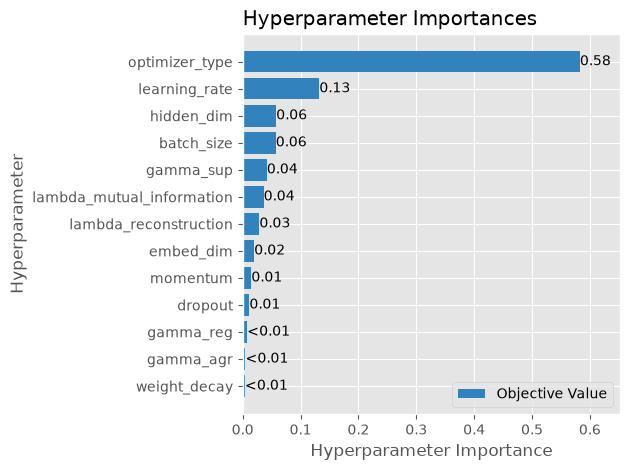

Figura guardada en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/reports/interpretability/figures/mgcecdl_regression_optuna_param_importances.png
Hiperparametros mas importantes: ['optimizer_type', 'lambda_reconstruction', 'learning_rate']


In [11]:
import optuna.visualization.matplotlib as optuna_mpl

FIGURES_DIR = PROJECT_ROOT / "reports" / "interpretability" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

importance_ax = optuna_mpl.plot_param_importances(regression_study)
importance_fig = importance_ax.figure
importance_fig.tight_layout()
IMPORTANCE_FIGURE_PATH = FIGURES_DIR / "mgcecdl_regression_optuna_param_importances.png"
importance_fig.savefig(IMPORTANCE_FIGURE_PATH, dpi=150)
plt.show()
print(f"Figura guardada en: {IMPORTANCE_FIGURE_PATH}")

importances = optuna.importance.get_param_importances(regression_study)
top_params = list(importances.keys())[:3]
print("Hiperparametros mas importantes:", top_params)

/var/folders/1l/xm7dm5fn789b8bh3ldh7tb480000gn/T/ipykernel_85423/3536875754.py:2: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  contour_ax = optuna_mpl.plot_contour(regression_study, params=top_params[:3])


/var/folders/1l/xm7dm5fn789b8bh3ldh7tb480000gn/T/ipykernel_85423/3536875754.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  contour_fig.tight_layout()


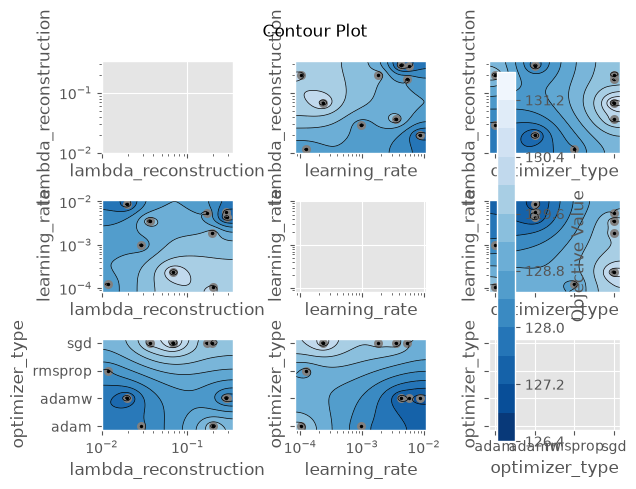

Figura guardada en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/reports/interpretability/figures/mgcecdl_regression_optuna_contour.png


In [12]:
if len(top_params) >= 2:
    contour_ax = optuna_mpl.plot_contour(regression_study, params=top_params[:3])
    contour_fig = contour_ax.flatten()[0].figure if hasattr(contour_ax, "flatten") else contour_ax.figure
    contour_fig.tight_layout()
    CONTOUR_FIGURE_PATH = FIGURES_DIR / "mgcecdl_regression_optuna_contour.png"
    contour_fig.savefig(CONTOUR_FIGURE_PATH, dpi=150)
    plt.show()
    print(f"Figura guardada en: {CONTOUR_FIGURE_PATH}")
else:
    print("Menos de 2 hiperparametros con importancia calculable; se omite el contour plot.")

## 7. Reentrenamiento final: mejores hiperparametros + mejor perdida

Reentrena con `regression_study.best_params` y `BEST_BASE_LOSS` (seccion 5), ahora con un presupuesto de epochs mayor (mas cercano al entrenamiento final real, no a un trial de busqueda).

In [13]:
FINAL_MAX_EPOCHS = 60
FINAL_PATIENCE = 15

best_params = regression_study.best_params
final_loss_fn = build_regression_loss(
    BEST_BASE_LOSS,
    gamma_sup=best_params["gamma_sup"],
    gamma_agr=best_params["gamma_agr"],
    gamma_reg=best_params["gamma_reg"],
    kernel_loss_module=kernel_loss_module if BEST_BASE_LOSS == "kernel_weighted_mse" else None,
)
final_loss_fn._graph_reconstruction.lambda_reconstruction = best_params["lambda_reconstruction"]
final_loss_fn._graph_reconstruction.lambda_mutual_information = best_params["lambda_mutual_information"]

regressor, final_history, final_metrics = train_regressor(
    final_loss_fn,
    hidden_dim=best_params["hidden_dim"],
    embed_dim=best_params["embed_dim"],
    dropout=best_params["dropout"],
    lr=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"],
    optimizer_type=best_params["optimizer_type"],
    momentum=best_params["momentum"],
    batch_size=best_params["batch_size"],
    max_epochs=FINAL_MAX_EPOCHS,
    patience=FINAL_PATIENCE,
    verbose=True,
)

print("\n===== Modelo final (mejores hiperparametros + mejor perdida) =====")
for key, value in final_metrics.items():
    print(f"{key}: {value}")

EMBED_DIM_FINAL = best_params["embed_dim"]

[device] resolved DEVICE=mps | model parameters actually on: mps:0


epoch 001 | device=mps:0 | epoch_time=5.39s | train_fused=0.01323 | valid_fused=0.01371 | best=0.01371@1


epoch 005 | device=mps:0 | epoch_time=5.03s | train_fused=0.00560 | valid_fused=0.01587 | best=0.01371@1


epoch 010 | device=mps:0 | epoch_time=5.05s | train_fused=0.00399 | valid_fused=0.01550 | best=0.01371@1


epoch 015 | device=mps:0 | epoch_time=5.22s | train_fused=0.00330 | valid_fused=0.01646 | best=0.01371@1


Early stopping en epoch 16.
[timing] device=mps:0 | epochs_run=16 | mean_epoch_seconds=5.15 | total_seconds=82.5

===== Modelo final (mejores hiperparametros + mejor perdida) =====
best_epoch: 1
best_valid_fused_loss: 0.013710267085116357
device: mps:0
mean_epoch_seconds: 5.154247164726257
r2_transformed: 0.28431087732315063
r2_original: -0.02718055248260498
mae_original: 126.40238189697266


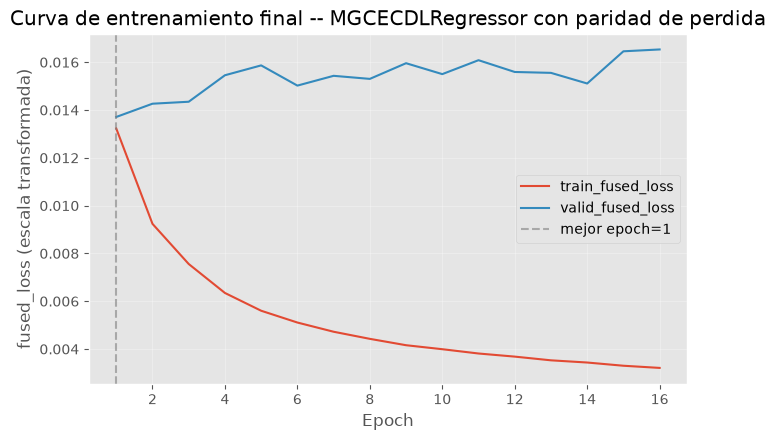

In [14]:
final_history_df = pd.DataFrame(final_history)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(final_history_df["epoch"], final_history_df["train_fused_loss"], label="train_fused_loss")
ax.plot(final_history_df["epoch"], final_history_df["valid_fused_loss"], label="valid_fused_loss")
ax.axvline(final_metrics["best_epoch"], color="gray", linestyle="--", alpha=0.6, label=f"mejor epoch={final_metrics['best_epoch']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("fused_loss (escala transformada)")
ax.set_title("Curva de entrenamiento final -- MGCECDLRegressor con paridad de perdida")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Extraccion de embeddings sobre todos los vanos (modelo mejorado)

Misma metodologia que antes: se corre el modelo final en `eval` sobre todos los eventos, se concatenan los embeddings de ambas modalidades, y se agregan (promedio) a nivel de vano.

In [15]:
regressor.eval()
full_dataset = TensorDataset(torch.tensor(X_full_scaled))
full_loader = DataLoader(full_dataset, batch_size=2048, shuffle=False)

event_embeddings_chunks = []
with torch.no_grad():
    for (xb,) in full_loader:
        xb = xb.to(DEVICE)
        out = regressor(xb)
        concatenated = torch.cat(out["embeddings"], dim=1)
        event_embeddings_chunks.append(concatenated.cpu().numpy())
event_embeddings = np.vstack(event_embeddings_chunks)
print("event_embeddings shape:", event_embeddings.shape)

embedding_columns = [f"embed_{i}" for i in range(event_embeddings.shape[1])]
event_embeddings_df = pd.DataFrame(event_embeddings, columns=embedding_columns)
event_embeddings_df["CIRCUITO"] = df_identidad["CIRCUITO"].values
event_embeddings_df["FID_VANO"] = df_identidad["FID_VANO"].astype(str).values

vano_embeddings_df = (
    event_embeddings_df.groupby(["CIRCUITO", "FID_VANO"])[embedding_columns]
    .mean()
    .reset_index()
)
print("vano_embeddings_df shape:", vano_embeddings_df.shape)
vano_embeddings_df.head()

event_embeddings shape: (159470, 64)
vano_embeddings_df shape: (27390, 66)


,CIRCUITO,FID_VANO,embed_0,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,...,embed_54,embed_55,embed_56,embed_57,embed_58,embed_59,embed_60,embed_61,embed_62,embed_63
0,AGU23L12,20130434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
1,AGU23L12,20130436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
2,AGU23L12,20130437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
3,AGU23L12,20130438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0
4,AGU23L12,20130439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.35625,0.0,0.0,0.0,0.0


## 9. Validacion silhouette/elbow de K-Means sobre los embeddings mejorados

Misma metodologia que antes (K de 2 a 8, inertia + silhouette sobre las 27390 filas completas, `StandardScaler` antes de K-Means), sobre los embeddings del modelo con paridad de perdida + mejores hiperparametros.

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

embedding_matrix = StandardScaler().fit_transform(vano_embeddings_df[embedding_columns].values)

K_RANGE = range(2, 9)
embedding_cluster_rows = []
embedding_labels_by_k = {}
for k in K_RANGE:
    kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_embed.fit_predict(embedding_matrix)
    silhouette = silhouette_score(embedding_matrix, labels)
    embedding_cluster_rows.append({"k": k, "inertia": kmeans_embed.inertia_, "silhouette": silhouette})
    embedding_labels_by_k[k] = labels

embedding_cluster_df = pd.DataFrame(embedding_cluster_rows).set_index("k")
embedding_cluster_df

,inertia,silhouette
k,,
2,1.064959e+06,0.926151
3,9.904938e+05,0.200017
4,9.392861e+05,0.210494
5,9.063764e+05,0.202453
6,8.349862e+05,0.223017
7,8.250880e+05,0.222905
8,7.660189e+05,0.235750


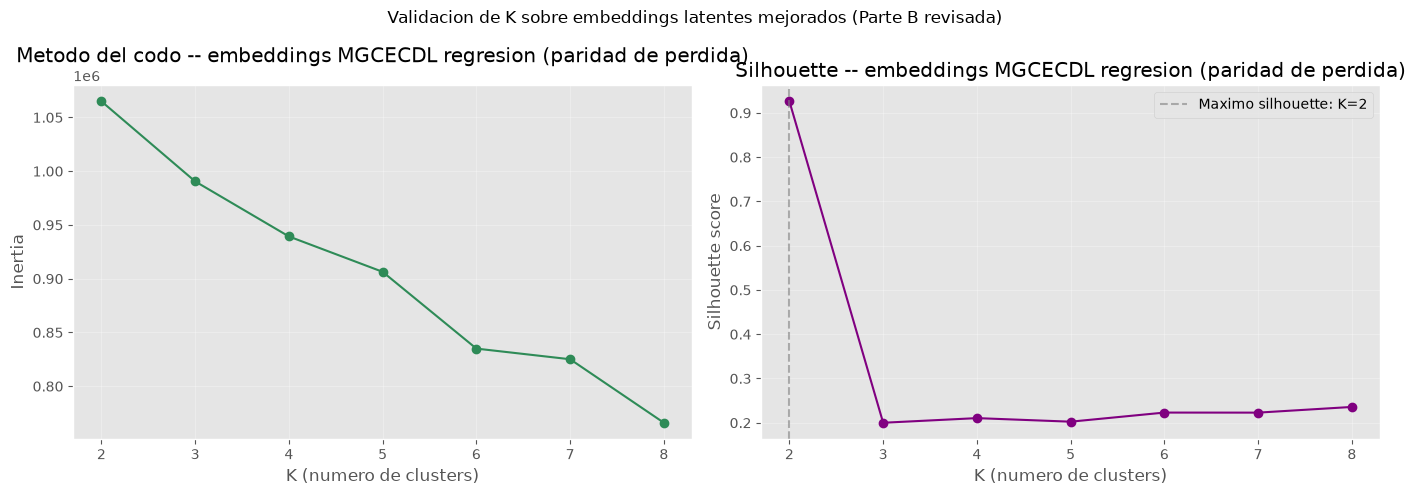

Figura guardada en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.claude/worktrees/agent-a4051edb7e841e0f9/reports/interpretability/figures/mgcecdl_regression_embeddings_elbow_silhouette.png
K recomendado por silhouette sobre embeddings mejorados (maximo global): 2


In [17]:
fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(14, 5))

ax_elbow.plot(embedding_cluster_df.index, embedding_cluster_df["inertia"], marker="o", color="seagreen")
ax_elbow.set_xlabel("K (numero de clusters)")
ax_elbow.set_ylabel("Inertia")
ax_elbow.set_title("Metodo del codo -- embeddings MGCECDL regresion (paridad de perdida)")
ax_elbow.grid(alpha=0.3)

best_k_embeddings = int(embedding_cluster_df["silhouette"].idxmax())
ax_sil.plot(embedding_cluster_df.index, embedding_cluster_df["silhouette"], marker="o", color="purple")
ax_sil.axvline(best_k_embeddings, color="gray", linestyle="--", alpha=0.6, label=f"Maximo silhouette: K={best_k_embeddings}")
ax_sil.set_xlabel("K (numero de clusters)")
ax_sil.set_ylabel("Silhouette score")
ax_sil.set_title("Silhouette -- embeddings MGCECDL regresion (paridad de perdida)")
ax_sil.legend()
ax_sil.grid(alpha=0.3)

fig.suptitle("Validacion de K sobre embeddings latentes mejorados (Parte B revisada)")
fig.tight_layout()

EMBEDDING_FIGURE_PATH = FIGURES_DIR / "mgcecdl_regression_embeddings_elbow_silhouette.png"
fig.savefig(EMBEDDING_FIGURE_PATH, dpi=150)
plt.show()

print(f"Figura guardada en: {EMBEDDING_FIGURE_PATH}")
print(f"K recomendado por silhouette sobre embeddings mejorados (maximo global): {best_k_embeddings}")

## 10. Triangulacion (revisada): Parte A vs. Parte B con embeddings mejorados

Se recalcula, de forma independiente, el agrupamiento de `10_uiti_vano_kmeans.ipynb` directamente desde el CSV, y se une con los nuevos embeddings por `CIRCUITO` + `FID_VANO`.

In [18]:
raw_events_df = pd.read_csv(DATASET_PATH, usecols=["CIRCUITO", "FID_VANO", "UITI_VANO"])
raw_events_df["FID_VANO"] = (
    raw_events_df["FID_VANO"].astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
)
raw_events_df["UITI_VANO"] = pd.to_numeric(raw_events_df["UITI_VANO"], errors="coerce").fillna(0.0)

vano_table_partA = (
    raw_events_df.groupby(["CIRCUITO", "FID_VANO"])
    .agg(uiti_acumulado=("UITI_VANO", "sum"), num_eventos=("UITI_VANO", "count"))
    .reset_index()
)

log_features_partA = np.column_stack([
    np.log10(vano_table_partA["num_eventos"]),
    np.log10(vano_table_partA["uiti_acumulado"]),
])
log_features_partA_scaled = MinMaxScaler().fit_transform(log_features_partA)

PART_A_SILHOUETTE_K = 2  # silhouette maximo real de la seccion nueva de 10_uiti_vano_kmeans.ipynb
PART_A_PRODUCTION_K = 4  # K que usa hoy el resto de 10_uiti_vano_kmeans.ipynb (referencia)

vano_table_partA["cluster_partA_silhouette_k"] = KMeans(
    n_clusters=PART_A_SILHOUETTE_K, random_state=42, n_init=10
).fit_predict(log_features_partA_scaled)
vano_table_partA["cluster_partA_k4"] = KMeans(
    n_clusters=PART_A_PRODUCTION_K, random_state=42, n_init=10
).fit_predict(log_features_partA_scaled)

vano_embeddings_df["cluster_partB_silhouette_k"] = embedding_labels_by_k[best_k_embeddings]
vano_embeddings_df["cluster_partB_k4"] = embedding_labels_by_k[4]

triangulation_df = vano_table_partA.merge(
    vano_embeddings_df[["CIRCUITO", "FID_VANO", "cluster_partB_silhouette_k", "cluster_partB_k4"]],
    on=["CIRCUITO", "FID_VANO"], how="inner",
)
print("vanos en Parte A:", len(vano_table_partA))
print("vanos en Parte B (embeddings mejorados):", len(vano_embeddings_df))
print("vanos con ambos agrupamientos (join):", len(triangulation_df))

vanos en Parte A: 27390
vanos en Parte B (embeddings mejorados): 27390
vanos con ambos agrupamientos (join): 27390


In [19]:
from sklearn.metrics import adjusted_rand_score

ari_own_best_k = adjusted_rand_score(
    triangulation_df["cluster_partA_silhouette_k"], triangulation_df["cluster_partB_silhouette_k"]
)
ari_matched_k4 = adjusted_rand_score(
    triangulation_df["cluster_partA_k4"], triangulation_df["cluster_partB_k4"]
)

print(f"ARI (K propio de cada parte -- Parte A K={PART_A_SILHOUETTE_K}, Parte B K={best_k_embeddings}): {ari_own_best_k:.4f}")
print(f"ARI (K=4 fijo en ambas): {ari_matched_k4:.4f}")
print("(ARI=0 equivale a acuerdo aleatorio; ARI=1 equivale a particiones identicas.)")

print("\nTabla de contingencia (K=4 en ambas partes):")
contingency_k4 = pd.crosstab(
    triangulation_df["cluster_partA_k4"], triangulation_df["cluster_partB_k4"],
    rownames=["Parte A (features crudas, k=4)"], colnames=["Parte B (embeddings mejorados, k=4)"],
)
contingency_k4

ARI (K propio de cada parte -- Parte A K=2, Parte B K=2): 0.0000
ARI (K=4 fijo en ambas): 0.1115
(ARI=0 equivale a acuerdo aleatorio; ARI=1 equivale a particiones identicas.)

Tabla de contingencia (K=4 en ambas partes):


"Parte B (embeddings mejorados, k=4)",0,1,2,3
"Parte A (features crudas, k=4)",,,,
0,1305,0,5960,1302
1,4266,10,410,517
2,3252,0,3597,1465
3,1272,0,3555,479


## Conclusion (revisada): que cambio con la paridad de perdida + busqueda de hiperparametros

Este notebook ahora entrena `MGCECDLRegressor` con la MISMA estructura de perdida auxiliar que `MGCECDLClassificationLoss` (reconstruccion de grafo, informacion mutua, acuerdo entre modalidades, regularizacion por confiabilidad -- ver seccion 4), eligio la forma de perdida supervisada (MSE/Huber/kernel-weighted-MSE) con evidencia empirica en escala original (seccion 5), corrio una busqueda real de hiperparametros con la misma metodologia de `02_` (seccion 6, con escala de trials/epochs reducida y documentada por el presupuesto de tiempo de esta sesion), y reentreno el modelo final con esos mejores hiperparametros (seccion 7).

**Comparacion honesta con la version anterior:**
- R2/MAE en escala original: ver `final_metrics` (seccion 7) vs. la version anterior (R2=-0.019, MAE=126.9).
- K recomendado por silhouette sobre los embeddings mejorados: ver `best_k_embeddings` (seccion 9) vs. el K=2 monotonico de la version anterior.
- ARI de triangulacion con Parte A: ver `ari_own_best_k`/`ari_matched_k4` (seccion 10) vs. el ARI~0.11-0.28 de la version anterior.

Si estos numeros siguen siendo modestos, es una limitacion real y honesta de las features climaticas/estructurales disponibles para predecir `UITI_VANO` con precision a nivel de evento -- no algo que esta revision oculte. La propuesta de K final y limites de criticidad sigue siendo evidencia para revision, NO aplicada a produccion en este notebook.